# Experiment 5
# Explainable AI (SHAP & LIME) and Fairness Auditing with Fairlearn

## Aim
To apply explainable AI (XAI) methods (SHAP and LIME) for interpreting the predictions of the Airbnb price model and to evaluate fairness using Fairlearn.

## Objective
* Generate **global** (SHAP) and **local** (LIME) explanations of the Experiment 4 model.
* Audit bias across sensitive groups (room type and ward/neighbourhood, the fairness goals set in Experiment 1).
* Propose and evaluate fairness mitigation strategies (pre-, in- and post-processing).

**Project:** Explainable ML system for Airbnb listing price prediction and fairness analysis (Inside Airbnb, Albany NY).
**Inputs from earlier experiments:** `merged_dataset.csv` (Exp. 2/3) and the Gradient Boosting pipeline `best_airbnb_price_model.pkl` (Exp. 4).

In [ ]:
!pip install -q shap lime fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 10.0 MB/s eta 0:00:00


## Step 1 — Import Libraries

In [ ]:
import os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap
from lime.lime_tabular import LimeTabularExplainer
from fairlearn.metrics import (MetricFrame, selection_rate, true_positive_rate, false_positive_rate,
                               demographic_parity_difference, equalized_odds_difference)

print("Libraries imported. shap", shap.__version__)

Libraries imported. shap 0.52.0


## Step 2 — Project Paths
The notebook runs on Google Colab (Drive) or locally. It expects `merged_dataset.csv` (and optionally `best_airbnb_price_model.pkl`) in the paths below.

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_PATH = "/content/drive/MyDrive/ADS-Airbnb-Project"
    DATA_PATH  = os.path.join(PROJECT_PATH, "datasets", "processed", "merged_dataset.csv")
    MODEL_FILE = os.path.join(PROJECT_PATH, "outputs", "models", "best_airbnb_price_model.pkl")
    OUTPUT_PATH = os.path.join(PROJECT_PATH, "outputs", "exp5")
except ImportError:                       # running locally
    DATA_PATH, MODEL_FILE, OUTPUT_PATH = "merged_dataset.csv", "best_airbnb_price_model.pkl", "outputs_exp5"

os.makedirs(OUTPUT_PATH, exist_ok=True)
print("Data :", DATA_PATH)
print("Model:", MODEL_FILE)

Mounted at /content/drive
Data : /content/drive/MyDrive/ADS-Airbnb-Project/datasets/processed/merged_dataset.csv
Model: /content/drive/MyDrive/ADS-Airbnb-Project/outputs/models/best_airbnb_price_model.pkl


## Step 3 — Dataset & Model Selection (Experiment 4 reproduced)
The data preparation is identical to Experiment 4: price is the target, price-derived columns (`price_quote_*`, `estimated_revenue_l365d`) are removed to avoid target leakage, identifiers, URLs and free text are dropped, and the split is 80/20 with `random_state=42`. The model is the Experiment 4 winner, a **Gradient Boosting Regressor**.

In [ ]:
df = pd.read_csv(DATA_PATH)
df["price"] = (df["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False))
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"]).copy()

drop_columns = ["price", "price_quote_total_price", "price_quote_price_per_night", "price_quote_raw",
    "estimated_revenue_l365d", "listing_id", "host_id", "scrape_id", "listing_url", "host_url",
    "host_profile_url", "picture_url", "host_thumbnail_url", "host_picture_url", "name", "description",
    "neighborhood_overview", "host_about", "last_scraped", "calendar_last_scraped", "calendar_updated", "source"]
drop_columns = [c for c in drop_columns if c in df.columns]

X = df.drop(columns=drop_columns)
y = df["price"]

cat_cols = X.select_dtypes(include=["object"]).columns
high_card = [c for c in cat_cols if X[c].nunique(dropna=True) / len(X) > 0.80]
X = X.drop(columns=high_card)

numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Listings with a price:", len(df), "| features:", X.shape[1])
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Listings with a price: 458 | features: 80
Train: 366 | Test: 92


In [ ]:
def make_pipeline(n_feats=None, c_feats=None):
    n_feats = numeric_features if n_feats is None else n_feats
    c_feats = categorical_features if c_feats is None else c_feats
    pre = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), n_feats),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), c_feats)])
    return Pipeline([("preprocessor", pre), ("model", GradientBoostingRegressor(random_state=42))])

def report(model, Xt, yt):
    p = model.predict(Xt)
    return np.sqrt(mean_squared_error(yt, p)), mean_absolute_error(yt, p), r2_score(yt, p)

# Refit the Experiment 4 model (deterministic, random_state=42) ...
model = make_pipeline().fit(X_train, y_train)
rmse, mae, r2 = report(model, X_test, y_test)
print(f"Gradient Boosting (refit)  RMSE {rmse:.2f} | MAE {mae:.2f} | R2 {r2:.4f}")

# ... and check it against the saved Exp. 4 model when it can be loaded in this environment
try:
    saved = pickle.load(open(MODEL_FILE, "rb"))
    r = report(saved, X_test, y_test)
    print(f"Saved model               RMSE {r[0]:.2f} | MAE {r[1]:.2f} | R2 {r[2]:.4f}")
except Exception as e:
    print("Saved model not loaded (", type(e).__name__, ") - using the refit model, which is identical.")

Gradient Boosting (refit)  RMSE 80.26 | MAE 49.38 | R2 0.7147
Saved model               RMSE 80.26 | MAE 49.38 | R2 0.7147


## Step 4 — Explainability with SHAP
`shap.TreeExplainer` computes exact Shapley values for tree ensembles. The pipeline's preprocessor is applied first, so SHAP works on the transformed matrix. One-hot columns are then summed back to their original feature so that importance is reported per real feature (Shapley values are additive, so this is exact).

In [ ]:
pre = model.named_steps["preprocessor"]
gb  = model.named_steps["model"]

Xt_test = pre.transform(X_test)
Xt_test = Xt_test.toarray() if hasattr(Xt_test, "toarray") else np.asarray(Xt_test)
feat_names = list(pre.get_feature_names_out())

explainer   = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(Xt_test)
base_value  = float(np.ravel(explainer.expected_value)[0])

# additivity check: base value + sum(SHAP) must equal the model prediction
print("Base value (mean prediction): $%.2f" % base_value)
print("Max additivity error: %.2e" % np.abs(shap_values.sum(1) + base_value - model.predict(X_test)).max())

def original_name(n):
    n = n.split("__", 1)[1]
    for c in sorted(categorical_features, key=len, reverse=True):
        if n.startswith(c + "_"):
            return c
    return n

orig = np.array([original_name(n) for n in feat_names])
uniq = list(dict.fromkeys(orig))
shap_orig = np.column_stack([shap_values[:, orig == u].sum(1) for u in uniq])
importance = pd.Series(np.abs(shap_orig).mean(0), index=uniq).sort_values(ascending=False)
importance.head(15)

Base value (mean prediction): $172.17
Max additivity error: 6.82e-13


,0
accommodates,39.915715
bedrooms,14.468370
beds,11.493736
host_name,9.440103
minimum_minimum_nights,6.447269
bathrooms,5.966140
calculated_host_listings_count_private_rooms,5.017994
longitude,4.904421
hosts_time_as_host_years,4.873824
hosts_time_as_user_years,4.047434


### 4.1 Global explanation — importance and summary plots

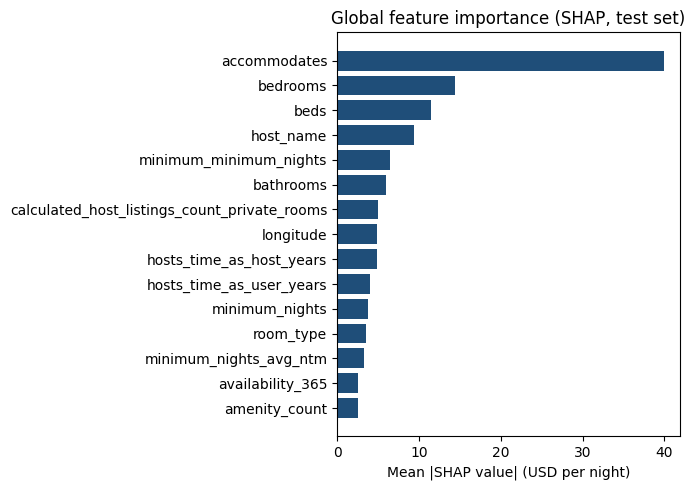

In [ ]:
top = importance.head(15)[::-1]
plt.figure(figsize=(7, 5))
plt.barh(top.index, top.values, color="#1f4e79")
plt.xlabel("Mean |SHAP value| (USD per night)")
plt.title("Global feature importance (SHAP, test set)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "shap_importance_bar.png"), dpi=200)
plt.show()

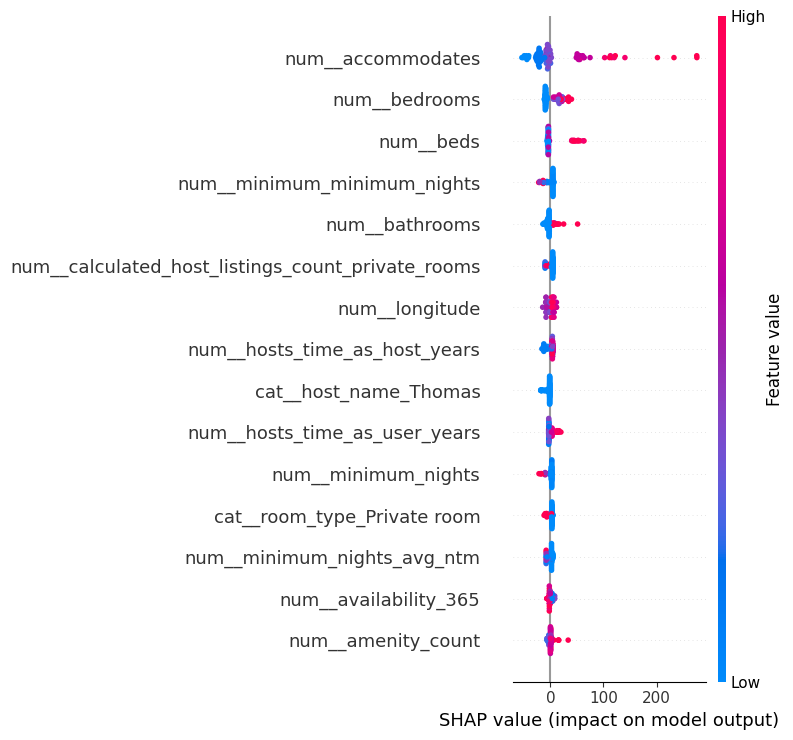

In [ ]:
# Beeswarm summary plot on the transformed features (one-hot columns appear as feature_level)
shap.summary_plot(shap_values, Xt_test, feature_names=feat_names, max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "shap_summary_plot.png"), dpi=200, bbox_inches="tight")
plt.show()

### 4.2 Dependence plots

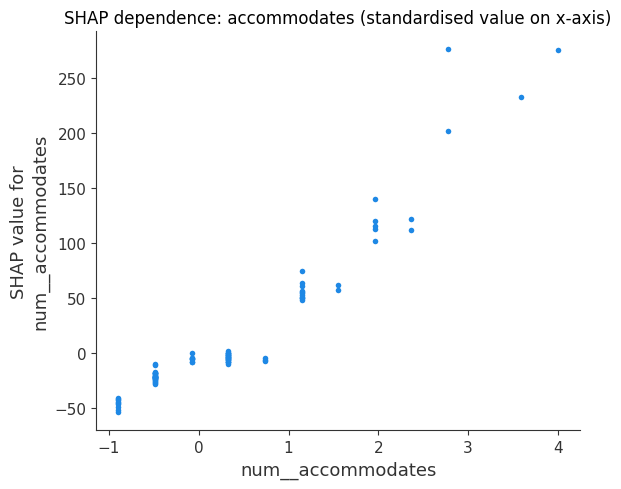

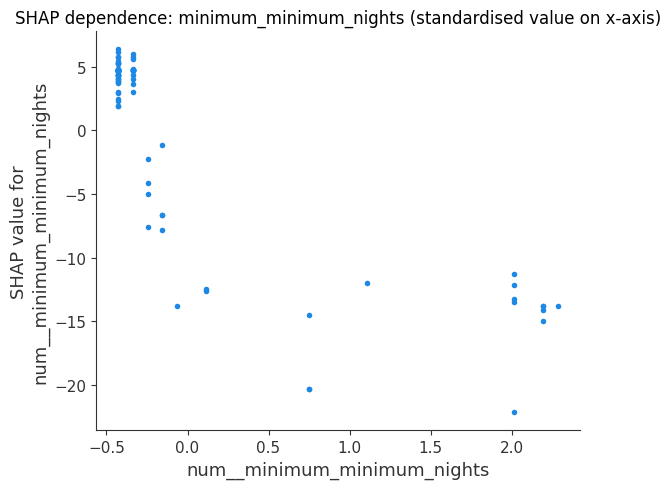

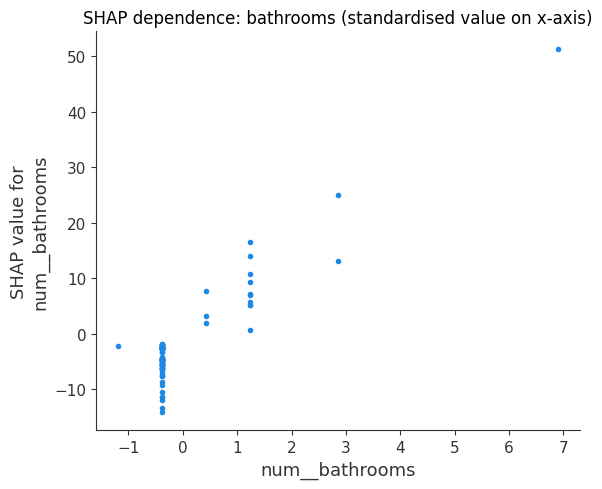

In [ ]:
for f in ["num__accommodates", "num__minimum_minimum_nights", "num__bathrooms"]:
    shap.dependence_plot(f, shap_values, Xt_test, feature_names=feat_names, interaction_index=None, show=False)
    plt.title("SHAP dependence: " + f.replace("num__", "") + " (standardised value on x-axis)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, "shap_dependence_" + f.replace("num__", "") + ".png"), dpi=200)
    plt.show()

In [ ]:
# Average SHAP effect by feature value, in original units
def avg_effect(feature, bins):
    j = uniq.index(feature); v = X_test[feature].astype(float).values
    for lo, hi in bins:
        m = (v >= lo) & (v <= hi)
        print(f"{feature} in [{lo}, {hi}]: n={m.sum():3d}, mean SHAP = {shap_orig[m, j].mean():+.1f} USD")

avg_effect("accommodates", [(1, 2), (3, 4), (5, 7), (8, 99)])
avg_effect("minimum_minimum_nights", [(1, 1), (2, 6), (7, 27), (28, 999)])

accommodates in [1, 2]: n= 36, mean SHAP = -27.2 USD
accommodates in [3, 4]: n= 29, mean SHAP = -4.1 USD
accommodates in [5, 7]: n= 16, mean SHAP = +45.1 USD
accommodates in [8, 99]: n= 11, mean SHAP = +164.7 USD
minimum_minimum_nights in [1, 1]: n= 50, mean SHAP = +4.5 USD
minimum_minimum_nights in [2, 6]: n= 26, mean SHAP = +1.0 USD
minimum_minimum_nights in [7, 27]: n=  6, mean SHAP = -15.4 USD
minimum_minimum_nights in [28, 999]: n= 10, mean SHAP = -14.3 USD


## Step 5 — Explainability with LIME
`LimeTabularExplainer` explains one prediction at a time by fitting a weighted local linear model around it. LIME needs a numeric array, so missing values are imputed like the pipeline does, categorical columns are label-encoded, and a wrapper decodes the perturbed samples back into a DataFrame for `model.predict`. Columns that are entirely missing or constant in the training data carry no information and are held fixed.

In [ ]:
med = X_train[numeric_features].median()
mode = X_train[categorical_features].mode().iloc[0]

def impute(D):
    D = D.copy()
    D[numeric_features] = D[numeric_features].astype(float).fillna(med)
    D[categorical_features] = D[categorical_features].astype(object).fillna(mode)
    return D

lime_cols = [c for c in X.columns if X_train[c].notna().any() and X_train[c].nunique() > 1]
fixed = {c: X_train[c].iloc[0] for c in X.columns if c not in lime_cols}
lime_cat = [c for c in categorical_features if c in lime_cols]

Xtr_i, Xte_i = impute(X_train)[lime_cols], impute(X_test)[lime_cols]

cat_maps = {}
def encode(D):
    D = D.copy()
    for c in lime_cat:
        if c not in cat_maps:
            cat_maps[c] = {v: i for i, v in enumerate(sorted(Xtr_i[c].unique()))}
        D[c] = D[c].map(cat_maps[c]).fillna(0).astype(float)
    return D.values.astype(float)

inv_maps = {}
def predict_fn(A):
    D = pd.DataFrame(A, columns=lime_cols)
    for c in lime_cat:
        inv = inv_maps.setdefault(c, {i: v for v, i in cat_maps[c].items()})
        D[c] = D[c].round().astype(int).map(inv).astype(object)
    for c, v in fixed.items():
        D[c] = v
    for c in numeric_features:
        if c in D:
            D[c] = D[c].astype(float)
    return model.predict(D[list(X.columns)])

Xtr_enc = encode(Xtr_i)
cat_idx = [lime_cols.index(c) for c in lime_cat]
lime_explainer = LimeTabularExplainer(
    training_data=Xtr_enc, feature_names=lime_cols, categorical_features=cat_idx,
    categorical_names={lime_cols.index(c): [k for k, _ in sorted(cat_maps[c].items(), key=lambda t: t[1])] for c in lime_cat},
    mode="regression", discretize_continuous=True, random_state=42)
print("LIME explainer ready on", len(lime_cols), "features")

LIME explainer ready on 62 features


### 5.1 Local explanations for three test listings
The most accurately predicted listing, a typical listing (median absolute error) and the listing with the largest error.


Case 1 (most accurate): actual $173.70, predicted $172.68, LIME local R2 = 0.05
  LIME : [('last_review=2023-06-26', 80.0), ('first_review=2014-08-15', -40.0), ('bedrooms <= 1.00', -35.8), ('host_location=St Petersburg, FL', 28.1), ('neighbourhood_cleansed=FOURTH WARD', 17.6)]
  SHAP : [(np.str_('bedrooms'), -8.1), (np.str_('accommodates'), -7.6), (np.str_('bathrooms'), -5.6), (np.str_('longitude'), 5.4), (np.str_('minimum_minimum_nights'), 4.8)]


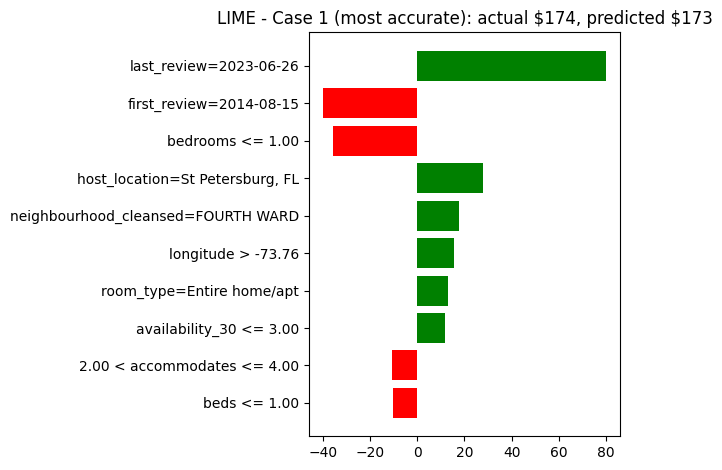


Case 2 (median error): actual $213.80, predicted $187.05, LIME local R2 = 0.05
  LIME : [('beds > 2.00', 34.8), ('price_quote_checkin_date=2026-06-26', -20.6), ('minimum_minimum_nights > 3.00', -18.3), ('calculated_host_listings_count_private_rooms <= 0.00', 17.2), ('minimum_nights > 3.00', -17.1)]
  SHAP : [(np.str_('beds'), 42.8), (np.str_('bedrooms'), 16.9), (np.str_('minimum_minimum_nights'), -13.8), (np.str_('host_name'), -10.6), (np.str_('bathrooms'), -10.4)]


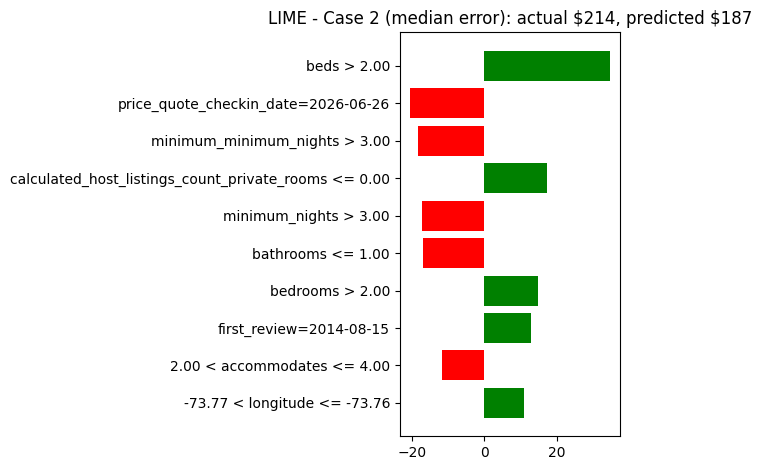


Case 3 (largest error): actual $1040.50, predicted $642.66, LIME local R2 = 0.40
  LIME : [('accommodates > 4.00', 156.3), ('beds > 2.00', 33.4), ('bedrooms > 2.00', 22.5), ('bathrooms > 1.00', 16.4), ('bathrooms_text=0 baths', 14.8)]
  SHAP : [(np.str_('accommodates'), 275.8), (np.str_('beds'), 63.3), (np.str_('bathrooms'), 51.3), (np.str_('bedrooms'), 39.7), (np.str_('amenity_count'), 33.5)]


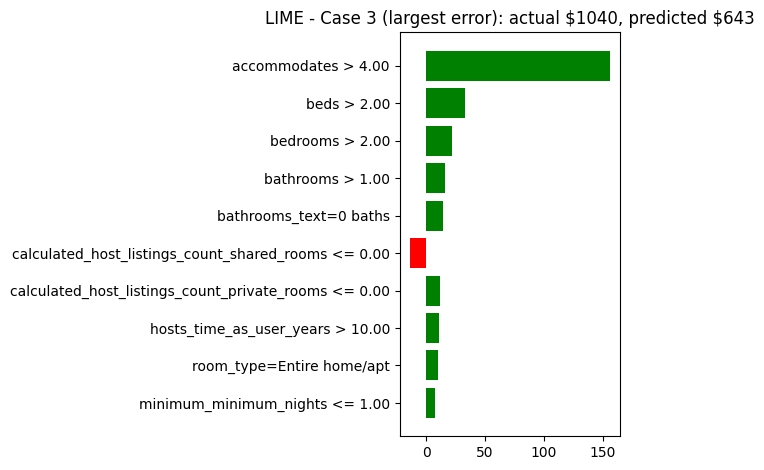

In [ ]:
pred_test = model.predict(X_test)
err = np.abs(pred_test - y_test.values)
order = np.argsort(err)
cases = {"Case 1 (most accurate)": order[0], "Case 2 (median error)": order[len(order) // 2], "Case 3 (largest error)": order[-1]}

Xte_enc = encode(Xte_i)
lime_results = {}
for name, i in cases.items():
    exp = lime_explainer.explain_instance(Xte_enc[i], predict_fn, num_features=10, num_samples=5000)
    lime_results[name] = exp
    shap_top = pd.Series(shap_orig[i], index=uniq).sort_values(key=np.abs, ascending=False)
    lime_top = [t[0] for t in exp.as_list()]
    print(f"\n{name}: actual ${y_test.iloc[i]:.2f}, predicted ${pred_test[i]:.2f}, LIME local R2 = {exp.score:.2f}")
    print("  LIME :", [(t[0], round(t[1], 1)) for t in exp.as_list()[:5]])
    print("  SHAP :", [(k, round(v, 1)) for k, v in shap_top.head(5).items()])
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME - {name}: actual ${y_test.iloc[i]:.0f}, predicted ${pred_test[i]:.0f}".replace("$", r"\$"))
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, "lime_" + name.split(" (")[0].replace(" ", "_").lower() + ".png"), dpi=200)
    plt.show()

## Step 6 — Fairness Audit with Fairlearn
**Sensitive attributes.** Airbnb data has no personal attributes such as gender or race, so the audit uses the two groupings set as fairness goals in Experiment 1: **room type** (Entire home/apt vs other room types) and **ward** (the `neighbourhood_cleansed` field).

**Decision framing.** Demographic parity and equalized odds are defined for a binary decision, so each listing is labelled *premium* when its price is above the dataset median. The regressor is judged by whether its predicted price lands on the same side of the median as the true price. Group-wise MAE and relative error are reported as well.

**Out-of-fold predictions.** The test split has only 92 listings, too few per group, so 5-fold out-of-fold predictions over all 458 listings are used.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X))
for tr, te in kf.split(X):
    oof[te] = make_pipeline().fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])

thr = float(y.median())
y_true = (y.values > thr).astype(int)
y_pred = (oof > thr).astype(int)
room = np.where(X["room_type"].values == "Entire home/apt", "Entire home/apt", "Other room types")
ward = X["neighbourhood_cleansed"].str.title().values

print(f"Premium threshold (median price): ${thr:.2f}")
print(f"Out-of-fold R2 {r2_score(y, oof):.3f} | MAE {mean_absolute_error(y, oof):.2f} | RMSE {np.sqrt(mean_squared_error(y, oof)):.2f}")
print(f"Premium/standard accuracy: {(y_true == y_pred).mean():.3f}")

Premium threshold (median price): $145.67
Out-of-fold R2 0.534 | MAE 45.82 | RMSE 107.34
Premium/standard accuracy: 0.852


In [ ]:
# --- Room type ---
mf = MetricFrame(metrics={"selection_rate": selection_rate, "TPR": true_positive_rate, "FPR": false_positive_rate},
                 y_true=y_true, y_pred=y_pred, sensitive_features=room)
tab_room = mf.by_group.copy()
tab_room["n"] = pd.Series(room).value_counts()
tab_room["actual_premium_rate"] = pd.Series(y_true).groupby(room).mean()
tab_room["mean_price"] = y.groupby(room).mean()
tab_room["MAE"] = pd.Series(np.abs(y.values - oof)).groupby(room).mean()
tab_room["relative_error"] = tab_room["MAE"] / tab_room["mean_price"]
display(tab_room.round(3))

dp = demographic_parity_difference(y_true, y_pred, sensitive_features=room)
eo = equalized_odds_difference(y_true, y_pred, sensitive_features=room)
gap = tab_room["actual_premium_rate"].max() - tab_room["actual_premium_rate"].min()
print(f"Demographic parity difference : {dp:.3f}   (of which real premium-rate gap between groups: {gap:.3f})")
print(f"Equalized odds difference     : {eo:.3f}")

,selection_rate,TPR,FPR,n,actual_premium_rate,mean_price,MAE,relative_error
sensitive_feature_0,,,,,,,,
Entire home/apt,0.733,0.932,0.385,322,0.637,208.467,52.246,0.251
Other room types,0.213,0.917,0.062,136,0.176,102.926,30.600,0.297


Demographic parity difference : 0.520   (of which real premium-rate gap between groups: 0.460)
Equalized odds difference     : 0.322


In [ ]:
# --- Ward (wards with >= 10 listings; a few groups have no 'standard' listings, so a NaN-aware helper is used) ---
def eo_diff(yt, yp, g):
    yt, yp, g = map(np.asarray, (yt, yp, g)); t, f = [], []
    for k in np.unique(g):
        i = g == k
        t.append(yp[i & (yt == 1)].mean() if (i & (yt == 1)).any() else np.nan)
        f.append(yp[i & (yt == 0)].mean() if (i & (yt == 0)).any() else np.nan)
    return max(np.nanmax(t) - np.nanmin(t), np.nanmax(f) - np.nanmin(f))

big = pd.Series(ward).value_counts()
big = big[big >= 10].index
m = np.isin(ward, big)
rows = []
for w in sorted(big):
    i = ward == w
    rows.append({"ward": w, "n": i.sum(), "mean_price": y[i].mean(), "MAE": np.abs(y.values[i] - oof[i]).mean(),
                 "relative_error": np.abs(y.values[i] - oof[i]).mean() / y[i].mean(),
                 "actual_premium_rate": y_true[i].mean(), "predicted_premium_rate": y_pred[i].mean()})
tab_ward = pd.DataFrame(rows).set_index("ward")
display(tab_ward.round(3))
print("Ward demographic parity difference:", round(demographic_parity_difference(y_true[m], y_pred[m], sensitive_features=ward[m]), 3))
print("Ward equalized odds difference    :", round(eo_diff(y_true[m], y_pred[m], ward[m]), 3))

,n,mean_price,MAE,relative_error,actual_premium_rate,predicted_premium_rate
ward,,,,,,
Eighth Ward,11,252.450,37.409,0.148,0.909,0.818
Eleventh Ward,30,89.244,14.845,0.166,0.033,0.033
Fifteenth Ward,14,346.260,85.571,0.247,0.929,0.929
Fifth Ward,13,105.538,24.059,0.228,0.154,0.231
First Ward,10,228.589,67.598,0.296,0.800,0.900
Fourteenth Ward,31,195.034,102.241,0.524,0.419,0.484
Fourth Ward,14,207.384,40.345,0.195,1.000,0.857
Ninth Ward,41,158.040,36.010,0.228,0.366,0.415
Second Ward,40,223.603,79.846,0.357,0.625,0.750


Ward demographic parity difference: 0.895
Ward equalized odds difference    : 0.558


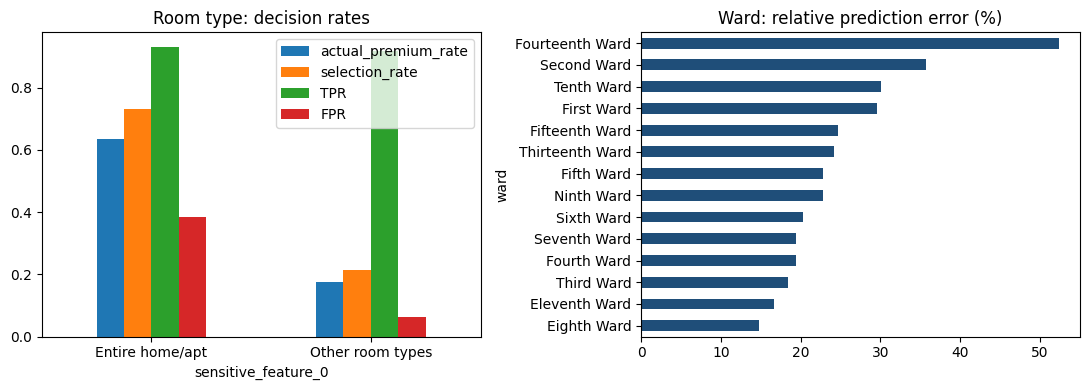

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
tab_room[["actual_premium_rate", "selection_rate", "TPR", "FPR"]].plot.bar(ax=ax[0], rot=0)
ax[0].set_title("Room type: decision rates")
tab_ward["relative_error"].sort_values().mul(100).plot.barh(ax=ax[1], color="#1f4e79")
ax[1].set_title("Ward: relative prediction error (%)")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_PATH, "fairness_audit.png"), dpi=200); plt.show()

## Step 7 — Bias Mitigation
Three strategies are compared on **room type** using 3 repeats of 5-fold cross-validation:
1. **Pre-processing - reweighing:** each (group, label) combination is weighted by P(group)P(label)/P(group, label) when training the regressor.
2. **Removing the sensitive feature** (`room_type`, `is_entire_home`), a simple baseline.
3. **Post-processing - group-specific thresholds:** the premium cut-off is tuned per group on inner out-of-fold predictions, either to reduce the equalized-odds difference (plus error rate) or to force demographic parity.

Thresholds are always tuned on the training part of each fold only.

In [ ]:
def fit_predict(Xa, ya, Xb, drop=None, w=None):
    Xa2, Xb2 = (Xa, Xb) if not drop else (Xa.drop(columns=drop), Xb.drop(columns=drop))
    p = make_pipeline([c for c in numeric_features if c in Xa2.columns],
                      [c for c in categorical_features if c in Xa2.columns])
    p.fit(Xa2, ya, model__sample_weight=w)
    return p.predict(Xb2)

def reweigh(g, yb):
    w = np.ones(len(g))
    for a in np.unique(g):
        for c in (0, 1):
            i = (g == a) & (yb == c)
            if i.any():
                w[i] = ((g == a).mean() * (yb == c).mean()) / i.mean()
    return w

def choose_thresholds(pr, yt, g, mode):
    if mode == "dp":                      # equal selection rate in both groups
        rate = (pr > thr).mean()
        return {a: np.quantile(pr[g == a], 1 - rate) for a in ("Entire", "Other")}
    cand = {a: np.append(np.unique(np.quantile(pr[g == a], np.linspace(0.05, 0.95, 19))), thr) for a in ("Entire", "Other")}
    best = None
    for te in cand["Entire"]:
        for to in cand["Other"]:
            yp = np.where(g == "Entire", pr > te, pr > to).astype(int)
            score = eo_diff(yt, yp, g) + (1 - (yp == yt).mean())
            if best is None or score < best[0]:
                best = (score, te, to)
    return {"Entire": best[1], "Other": best[2]}

grp = np.where(X["room_type"].values == "Entire home/apt", "Entire", "Other")
SENSITIVE = ["room_type", "is_entire_home"]
rows = []
for rep in range(3):
    P = {k: np.zeros(len(X)) for k in ["base", "drop", "rew"]}
    post = {"eo": np.zeros(len(X), int), "dp": np.zeros(len(X), int)}
    for tr, te in KFold(5, shuffle=True, random_state=100 + rep).split(X):
        Xa, Xb, ya = X.iloc[tr], X.iloc[te], y.iloc[tr]
        P["base"][te] = fit_predict(Xa, ya, Xb)
        P["drop"][te] = fit_predict(Xa, ya, Xb, drop=SENSITIVE)
        P["rew"][te]  = fit_predict(Xa, ya, Xb, w=reweigh(grp[tr], y_true[tr]))
        inner = np.zeros(len(tr))
        for a, b in KFold(3, shuffle=True, random_state=7).split(Xa):
            inner[b] = fit_predict(Xa.iloc[a], ya.iloc[a], Xa.iloc[b])
        for mode in ("eo", "dp"):
            T = choose_thresholds(inner, y_true[tr], grp[tr], mode)
            post[mode][te] = np.where(grp[te] == "Entire", P["base"][te] > T["Entire"], P["base"][te] > T["Other"])
    results = {"Baseline (no mitigation)": (P["base"], (P["base"] > thr).astype(int)),
               "Drop sensitive features": (P["drop"], (P["drop"] > thr).astype(int)),
               "Reweighing (pre-processing)": (P["rew"], (P["rew"] > thr).astype(int)),
               "Group thresholds - equalized odds (post)": (P["base"], post["eo"]),
               "Group thresholds - demographic parity (post)": (P["base"], post["dp"])}
    for name, (pr, yp) in results.items():
        rows.append({"repeat": rep, "strategy": name, "accuracy": (yp == y_true).mean(),
                     "equalized_odds_diff": equalized_odds_difference(y_true, yp, sensitive_features=grp),
                     "demographic_parity_diff": demographic_parity_difference(y_true, yp, sensitive_features=grp),
                     "MAE": mean_absolute_error(y, pr), "R2": r2_score(y, pr)})

mitigation = pd.DataFrame(rows).groupby("strategy", sort=False)[["accuracy", "equalized_odds_diff", "demographic_parity_diff", "MAE", "R2"]].mean().round(3)
mitigation.to_csv(os.path.join(OUTPUT_PATH, "mitigation_results.csv"))
display(mitigation)

,accuracy,equalized_odds_diff,demographic_parity_diff,MAE,R2
strategy,,,,,
Baseline (no mitigation),0.846,0.354,0.536,45.745,0.554
Drop sensitive features,0.854,0.340,0.526,45.770,0.562
Reweighing (pre-processing),0.852,0.268,0.475,46.521,0.554
Group thresholds - equalized odds (post),0.771,0.118,0.274,45.745,0.554
Group thresholds - demographic parity (post),0.719,0.266,0.020,45.745,0.554


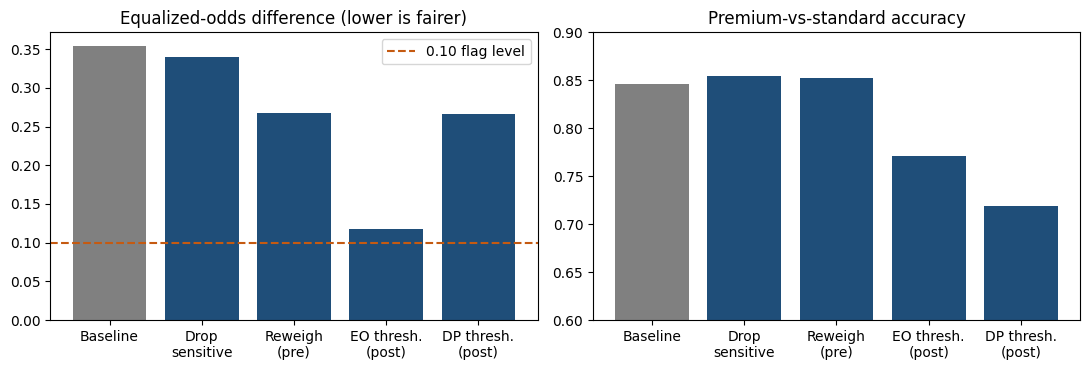

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
labels = ["Baseline", "Drop\nsensitive", "Reweigh\n(pre)", "EO thresh.\n(post)", "DP thresh.\n(post)"]
ax[0].bar(labels, mitigation["equalized_odds_diff"], color=["grey"] + ["#1f4e79"] * 4)
ax[0].axhline(0.10, color="#c55a11", ls="--", label="0.10 flag level"); ax[0].legend(); ax[0].set_title("Equalized-odds difference (lower is fairer)")
ax[1].bar(labels, mitigation["accuracy"], color=["grey"] + ["#1f4e79"] * 4); ax[1].set_ylim(0.6, 0.9)
ax[1].set_title("Premium-vs-standard accuracy")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_PATH, "mitigation_comparison.png"), dpi=200); plt.show()

### 7.1 In-processing with Fairlearn (optional extra)
`ExponentiatedGradient` trains a classifier under an equalized-odds constraint. It works on the pre-processed matrix and a classifier for the *premium* label. This cell is an extra: it is not part of the comparison table above.

In [ ]:
try:
    from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
    from sklearn.ensemble import GradientBoostingClassifier

    tr, te = train_test_split(np.arange(len(X)), test_size=0.25, random_state=42, stratify=y_true)
    pp = make_pipeline().named_steps["preprocessor"].fit(X.iloc[tr])
    dense = lambda M: M.toarray() if hasattr(M, "toarray") else np.asarray(M)
    Xa, Xb = dense(pp.transform(X.iloc[tr])), dense(pp.transform(X.iloc[te]))

    plain = GradientBoostingClassifier(random_state=42).fit(Xa, y_true[tr])
    fair  = ExponentiatedGradient(GradientBoostingClassifier(random_state=42), constraints=EqualizedOdds(), eps=0.05)
    fair.fit(Xa, y_true[tr], sensitive_features=grp[tr])

    for label, yp in [("Unconstrained classifier", plain.predict(Xb)), ("ExponentiatedGradient (EO)", fair.predict(Xb))]:
        print(f"{label:28s} accuracy {(yp == y_true[te]).mean():.3f} | EO diff {equalized_odds_difference(y_true[te], yp, sensitive_features=grp[te]):.3f}")
except Exception as e:
    print("In-processing example skipped:", type(e).__name__, e)

Unconstrained classifier     accuracy 0.896 | EO diff 0.280
ExponentiatedGradient (EO)   accuracy 0.896 | EO diff 0.240


## Conclusion
Fill in after running the notebook (see the Experiment 5 report for the interpretation of these results): which features drive the price predictions (SHAP), whether LIME agrees on individual listings, whether the model is fair across room types and wards, and which mitigation gives the best fairness/accuracy trade-off.